In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [11]:
# Dataset Loading
df = pd.read_csv("train.csv")
print(df.shape)
print(df.head())
print('\n')
print('Columns:', df.columns.tolist())
print('\n')
print(df.dtypes)
print('\n')
print(df.info())
print('\n')
print(df.isnull().sum())

(630000, 15)
   id  Age  Sex  Chest pain type   BP  Cholesterol  FBS over 120  EKG results  \
0   0   58    1                4  152          239             0            0   
1   1   52    1                1  125          325             0            2   
2   2   56    0                2  160          188             0            2   
3   3   44    0                3  134          229             0            2   
4   4   58    1                4  140          234             0            2   

   Max HR  Exercise angina  ST depression  Slope of ST  \
0     158                1            3.6            2   
1     171                0            0.0            1   
2     151                0            0.0            1   
3     150                0            1.0            2   
4     125                1            3.8            2   

   Number of vessels fluro  Thallium Heart Disease  
0                        2         7      Presence  
1                        0         3       Ab

In [12]:
# Encoding target column to 1 / 0 
df['Heart Disease'] = df['Heart Disease'].map({'Presence': 1, 'Absence': 0})
print(df['Heart Disease'].value_counts())

Heart Disease
0    347546
1    282454
Name: count, dtype: int64


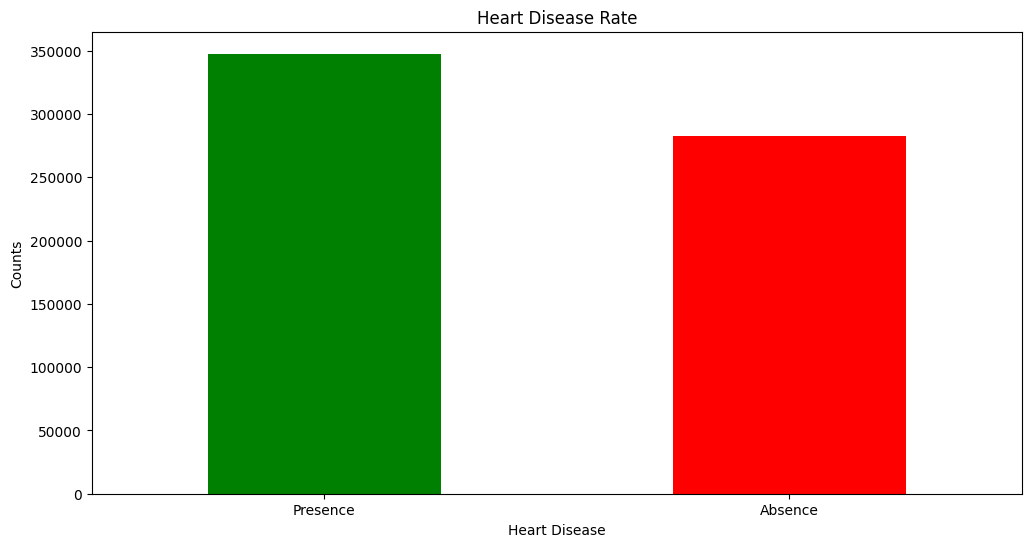

Heart Disease
0    347546
1    282454
Name: count, dtype: int64


In [17]:
df['Heart Disease'].value_counts().plot(kind='bar', color = ['green', 'red'], figsize=(12,6))
plt.xlabel('Heart Disease')
plt.ylabel('Counts')
plt.xticks([0, 1],['Presence', 'Absence'], rotation=0)
plt.title('Heart Disease Rate')
plt.show()

print(df['Heart Disease'].value_counts())

In [18]:
print(df.describe())

                  id            Age            Sex  Chest pain type  \
count  630000.000000  630000.000000  630000.000000    630000.000000   
mean   314999.500000      54.136706       0.714735         3.312752   
std    181865.479132       8.256301       0.451541         0.851615   
min         0.000000      29.000000       0.000000         1.000000   
25%    157499.750000      48.000000       0.000000         3.000000   
50%    314999.500000      54.000000       1.000000         4.000000   
75%    472499.250000      60.000000       1.000000         4.000000   
max    629999.000000      77.000000       1.000000         4.000000   

                  BP    Cholesterol   FBS over 120    EKG results  \
count  630000.000000  630000.000000  630000.000000  630000.000000   
mean      130.497433     245.011814       0.079987       0.981660   
std        14.975802      33.681581       0.271274       0.998783   
min        94.000000     126.000000       0.000000       0.000000   
25%       120.0

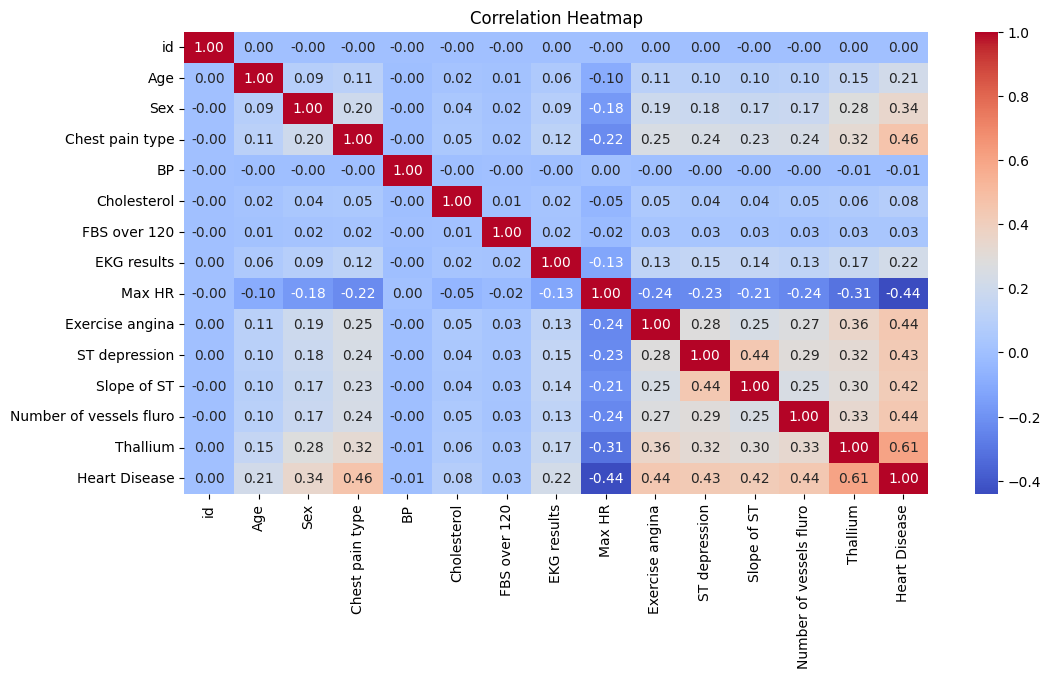

In [19]:
plt.figure(figsize=(12,6))
sns.heatmap(df.corr(), annot=True, fmt='.2f', cmap='coolwarm')
plt.title('Correlation Heatmap')
plt.show()

In [20]:
print(df['Thallium'].value_counts())

Thallium
3    372286
7    246748
6     10966
Name: count, dtype: int64


In [21]:
df.groupby('Thallium')['Heart Disease'].mean()

Thallium
3    0.198049
6    0.686394
7    0.815391
Name: Heart Disease, dtype: float64

In [22]:
df = df.drop('id', axis=1)
print(df.shape)

(630000, 14)


In [23]:
X = df.drop('Heart Disease', axis=1)
y = df['Heart Disease']

print(X.shape, '\n', y.shape)

(630000, 13) 
 (630000,)


In [24]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=23)

print(f'Train: {X_train.shape}')
print(f'Test: {X_test.shape}')

Train: (504000, 13)
Test: (126000, 13)


In [25]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [26]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, roc_auc_score, classification_report

In [28]:
lr = LogisticRegression(max_iter=1000)
lr.fit(X_train, y_train)

y_pred = lr.predict(X_test)
y_prob = lr.predict_proba(X_test)[:, 1]

In [29]:
print(f"Accuracy: {accuracy_score(y_test, y_pred):.4f}")
print(f"ROC-AUC: {roc_auc_score(y_test, y_prob):.4f}")
print(classification_report(y_test, y_pred))

Accuracy: 0.8833
ROC-AUC: 0.9510
              precision    recall  f1-score   support

           0       0.88      0.91      0.90     69180
           1       0.88      0.86      0.87     56820

    accuracy                           0.88    126000
   macro avg       0.88      0.88      0.88    126000
weighted avg       0.88      0.88      0.88    126000



In [30]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)
y_prob_rf = rf.predict_proba(X_test)[:, 1]

In [31]:
print(f"Accuracy: {accuracy_score(y_test, y_pred_rf):.4f}")
print(f"ROC-AUC: {roc_auc_score(y_test, y_prob_rf):.4f}")
print(classification_report(y_test, y_pred_rf))

Accuracy: 0.8813
ROC-AUC: 0.9473
              precision    recall  f1-score   support

           0       0.89      0.90      0.89     69180
           1       0.88      0.86      0.87     56820

    accuracy                           0.88    126000
   macro avg       0.88      0.88      0.88    126000
weighted avg       0.88      0.88      0.88    126000



In [32]:
from xgboost import XGBClassifier

xgb = XGBClassifier(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=5,
    random_state=42,
    n_jobs=-1,
    eval_metric='auc'
)
xgb.fit(X_train, y_train)

y_pred_xgb = xgb.predict(X_test)
y_prob_xgb = xgb.predict_proba(X_test)[:, 1]

print(f"Accuracy: {accuracy_score(y_test, y_pred_xgb):.4f}")
print(f"ROC-AUC: {roc_auc_score(y_test, y_prob_xgb):.4f}")
print(classification_report(y_test, y_pred_xgb))

Accuracy: 0.8878
ROC-AUC: 0.9549
              precision    recall  f1-score   support

           0       0.89      0.91      0.90     69180
           1       0.88      0.87      0.87     56820

    accuracy                           0.89    126000
   macro avg       0.89      0.89      0.89    126000
weighted avg       0.89      0.89      0.89    126000



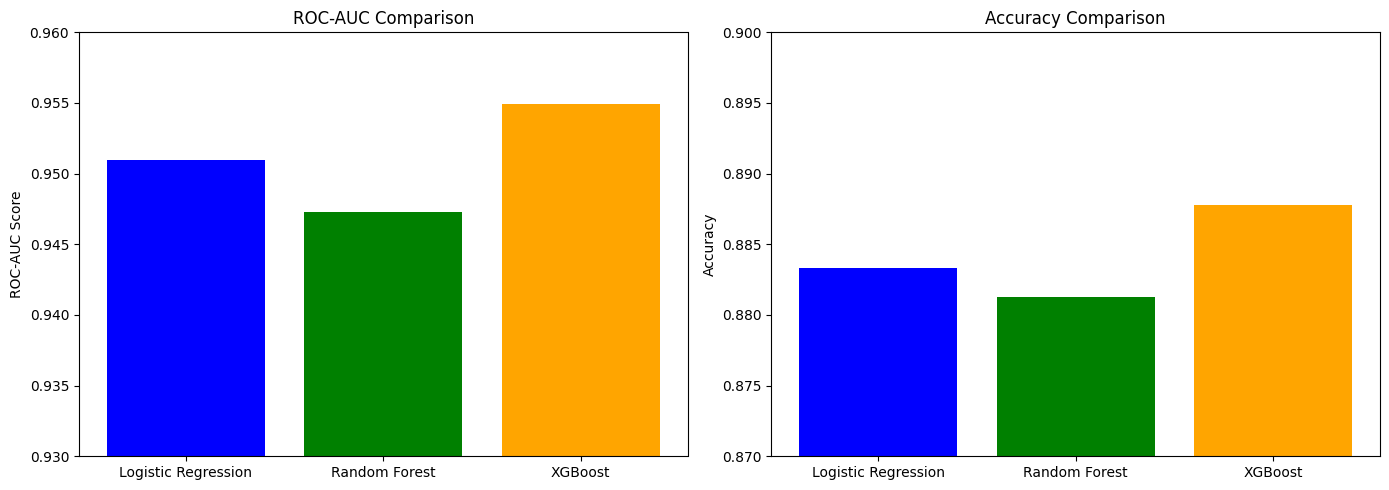

In [33]:
# Model Comparison
models = ['Logistic Regression', 'Random Forest', 'XGBoost']
roc_scores = [0.9510, 0.9473, 0.9549]
accuracies = [0.8833, 0.8813, 0.8878]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].bar(models, roc_scores, color=['blue', 'green', 'orange'])
axes[0].set_title('ROC-AUC Comparison')
axes[0].set_ylim(0.93, 0.96)
axes[0].set_ylabel('ROC-AUC Score')

axes[1].bar(models, accuracies, color=['blue', 'green', 'orange'])
axes[1].set_title('Accuracy Comparison')
axes[1].set_ylim(0.87, 0.90)
axes[1].set_ylabel('Accuracy')

plt.tight_layout()
plt.show()

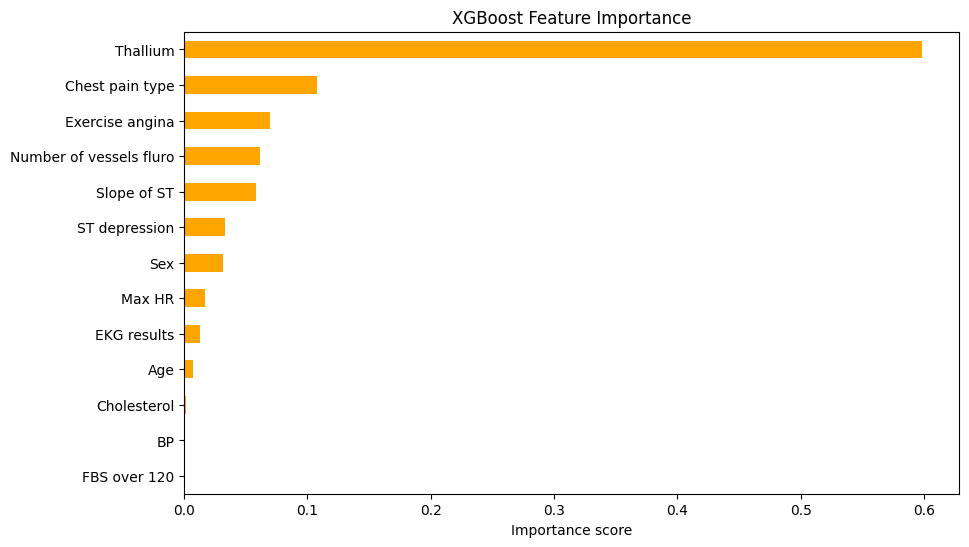

In [36]:
feat_imp = pd.Series(xgb.feature_importances_, index=X.columns)
feat_imp.sort_values().plot(kind='barh', figsize=(10,6), color='orange')
plt.title('XGBoost Feature Importance')
plt.xlabel('Importance score')
plt.show()

In [ ]:
'''
Contrary to popular belief, Blood Pressure and Cholesterol are weak predictors.
Thallium stress test result is by far the most diagnostic feature.
'''